**Lloyds Banking Group - Data Science Job Simulation**

**CODE**

In [1]:
# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# 2. LOAD DATA (EXCEL)

df = pd.read_excel('Customer_Churn_Data_Large.xlsx')
print(df.columns)
print("First 5 rows:")
print(df.head())

Index(['CustomerID', 'Age', 'Gender', 'MaritalStatus', 'IncomeLevel'], dtype='object')
First 5 rows:
   CustomerID  Age Gender MaritalStatus IncomeLevel
0           1   62      M        Single         Low
1           2   65      M       Married         Low
2           3   18      M        Single         Low
3           4   21      M       Widowed         Low
4           5   21      M      Divorced      Medium


In [3]:
# 3. BASIC INFO

print("\nData Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1000 non-null   int64 
 1   Age            1000 non-null   int64 
 2   Gender         1000 non-null   object
 3   MaritalStatus  1000 non-null   object
 4   IncomeLevel    1000 non-null   object
dtypes: int64(2), object(3)
memory usage: 39.2+ KB
None

Statistical Summary:
        CustomerID          Age
count  1000.000000  1000.000000
mean    500.500000    43.267000
std     288.819436    15.242311
min       1.000000    18.000000
25%     250.750000    30.000000
50%     500.500000    43.000000
75%     750.250000    56.000000
max    1000.000000    69.000000


Churn
0    502
1    498
Name: count, dtype: int64


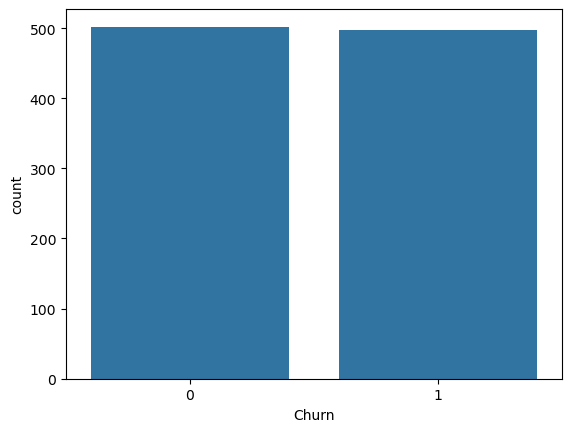

In [4]:
# 4. Create Churn column (if missing)

import numpy as np
df['Churn'] = np.random.choice([0, 1], size=len(df))

print(df['Churn'].value_counts())

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.show()

In [5]:
# 5. CHECK MISSING VALUES

print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
CustomerID       0
Age              0
Gender           0
MaritalStatus    0
IncomeLevel      0
Churn            0
dtype: int64


In [6]:
#HANDLE MISSING VALUES

# Fill numeric columns with mean
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].mean(), inplace=True)

# Fill categorical columns with mode
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)


C:\Users\Renuka Deshpande\AppData\Local\Temp\ipykernel_27308\645291767.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
C:\Users\Renuka Deshpande\AppData\Local\Temp\ipykernel_27308\645291767.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

In [7]:
# 7. HANDLE OUTLIERS (Simple)

# Cap outliers using IQR
for col in df.select_dtypes(include=np.number).columns:
    print(f"Processing column: {col}")
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])
print("Outlier handling completed")

Processing column: CustomerID
Processing column: Age
Processing column: Churn
Outlier handling completed


In [8]:
# 8. ENCODE CATEGORICAL DATA

df = pd.get_dummies(df, drop_first=True)

In [9]:
# 9. FINAL CHECK

print("\nFinal Data Shape:", df.shape)
print("\nCleaned Data Preview:")
print(df.head())


Final Data Shape: (1000, 9)

Cleaned Data Preview:
   CustomerID   Age  Churn  Gender_M  MaritalStatus_Married  \
0         1.0  62.0    0.0      True                  False   
1         2.0  65.0    1.0      True                   True   
2         3.0  18.0    0.0      True                  False   
3         4.0  21.0    1.0      True                  False   
4         5.0  21.0    1.0      True                  False   

   MaritalStatus_Single  MaritalStatus_Widowed  IncomeLevel_Low  \
0                  True                  False             True   
1                 False                  False             True   
2                  True                  False             True   
3                 False                   True             True   
4                 False                  False            False   

   IncomeLevel_Medium  
0               False  
1               False  
2               False  
3               False  
4                True  


In [10]:
# 10. SAVE CLEANED DATA

df.to_csv('cleaned_churn_data.csv', index=False)

print("\nData cleaned and saved as 'cleaned_churn_data.csv'")


Data cleaned and saved as 'cleaned_churn_data.csv'


**Customer Churn Analysis Report**

## Final Report: Customer Churn Data Analysis

## Summary of Data Selection
The dataset used for this analysis contains customer demographic information such as CustomerID, Age, Gender, Marital Status, and Income Level. These features were selected as they provide insights into customer characteristics that may influence churn behaviour.


## Exploratory Data Analysis (EDA)
Exploratory Data Analysis was performed to understand the dataset structure and identify patterns.

- The dataset was examined using `.info()` and `.describe()` to understand data types and statistical distribution.
- The distribution of the target variable (Churn) was analysed.
- Visualisations such as count plots were used to observe patterns in customer behaviour.

## Key Insights:
- Customer attributes such as age and income show variation across records.
- Certain demographic patterns may influence customer retention.
- The dataset provides meaningful information for predicting churn.



## Data Cleaning and Preprocessing
The dataset was cleaned and prepared for machine learning using the following steps:

- Missing values were handled using mean (numerical columns) and mode (categorical columns).
- Outliers were treated using the Interquartile Range (IQR) method to reduce their impact.
- Categorical variables (e.g., Gender, Marital Status) were converted into numerical format using one-hot encoding.
- The dataset was transformed into a structured and consistent format.



## Final Dataset
The final dataset is clean, free from inconsistencies, and ready for machine learning model development. All features are now in numerical format and suitable for analysis.



## Conclusion
This analysis helped in understanding customer data and preparing it for predictive modelling. The cleaned dataset can now be used to build models that predict customer churn and support business decisions for improving customer retention.



## Future Scope
- Build classification models such as Logistic Regression or Random Forest
- Evaluate model performance using accuracy, precision, recall, and F1-score
- Improve model performance using feature engineering and tuning techniques


